
# Section 3 b - Create Quantum Circuits (Transpile circuits)

## Certification weight: 18%

## Objectives 
- Construct dynamic circuits
- Construct parameterized circuits
- Transpile and optimize circuits
- Construct basic quantum circuits

Resources:
https://quantum.cloud.ibm.com/docs/en/guides/transpile



## Analogy
The goal of the transpiler is like a compiler: is to translate a high-level circuit to an executable one (regarding qubits connections - CouplingMap and instructions available - Basis gates)

For that, the transpiler leverage Passes, launched by PassManagers:
- StagedPassManager orchestrates the execution of one or more PassManagers, and determines their orders
- PassManagers is a collection of passes
- Pass objects are transformations or analysis on the circuit




## Transpilation invokation
- with default parameters, using the `transpile` function, setting an `optimization_level`from 0 to 3 (higher is more optimized). Although it's the simplest way to transpile a circuit, this method is deprecated, and may be removed in a future version.
- with pass managers using `generate_preset_pass_manager`
- by creating our own `PassManager`

## Transpiler stages
1. init - Include your own initial optimizations
2. layout - Maps the circuit with the physical layout (coupling map)
3. routing - adds swap gates to connect non-adgacent qubits
4. translation - Convert gates into basis gates
5. optimization - Removes unneeded gates (two gates that cancels eatch others, ...)
6. scheduling - Add delays to synchronize gates between qubits 


## Transpiler passes
The passes list are described in the documentation https://quantum.cloud.ibm.com/docs/en/api/qiskit/transpiler_passes

It's possible to print the list of the passes:

In [27]:
from qiskit.transpiler import passes
dir(passes)

['ALAPScheduleAnalysis',
 'AQCSynthesisPlugin',
 'ASAPScheduleAnalysis',
 'ApplyLayout',
 'BarrierBeforeFinalMeasurements',
 'BasicSwap',
 'BasisTranslator',
 'CSPLayout',
 'CheckGateDirection',
 'CheckMap',
 'CliffordUnitarySynthesis',
 'Collect1qRuns',
 'Collect2qBlocks',
 'CollectAndCollapse',
 'CollectCliffords',
 'CollectLinearFunctions',
 'CollectMultiQBlocks',
 'CommutationAnalysis',
 'CommutativeCancellation',
 'CommutativeInverseCancellation',
 'CommutativeOptimization',
 'Commuting2qGateRouter',
 'ConsolidateBlocks',
 'ConstrainedReschedule',
 'ContainsInstruction',
 'ContextAwareDynamicalDecoupling',
 'ContractIdleWiresInControlFlow',
 'CountOps',
 'CountOpsLongestPath',
 'DAGFixedPoint',
 'DAGLongestPath',
 'Decompose',
 'DenseLayout',
 'Depth',
 'ElidePermutations',
 'EnlargeWithAncilla',
 'Error',
 'FilterOpNodes',
 'FixedPoint',
 'FullAncillaAllocation',
 'GateDirection',
 'GatesInBasis',
 'HLSConfig',
 'HighLevelSynthesis',
 'HoareOptimizer',
 'InstructionDurationCheck'

## Transpile with Pass Manager

In this example, we will transpile a simple circuit using a Paris backend

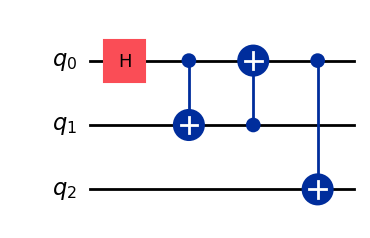

In [1]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 0)
qc.cx(0, 2)
qc.draw("mpl")


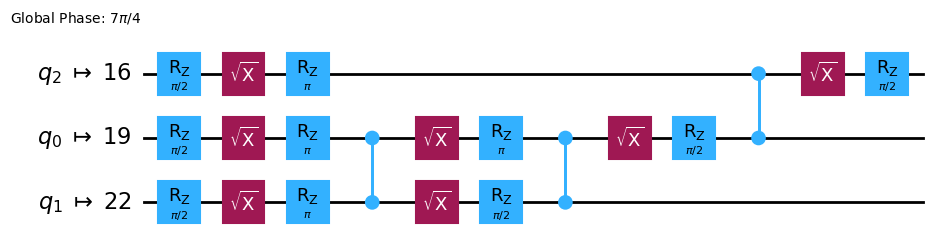

In [2]:
from qiskit_ibm_runtime.fake_provider import FakePrague

backend = FakePrague()
pass_manager = generate_preset_pass_manager(
    optimization_level=3, backend=backend
)
transpiled = pass_manager.run(qc)
transpiled.draw("mpl", idle_wires=False)

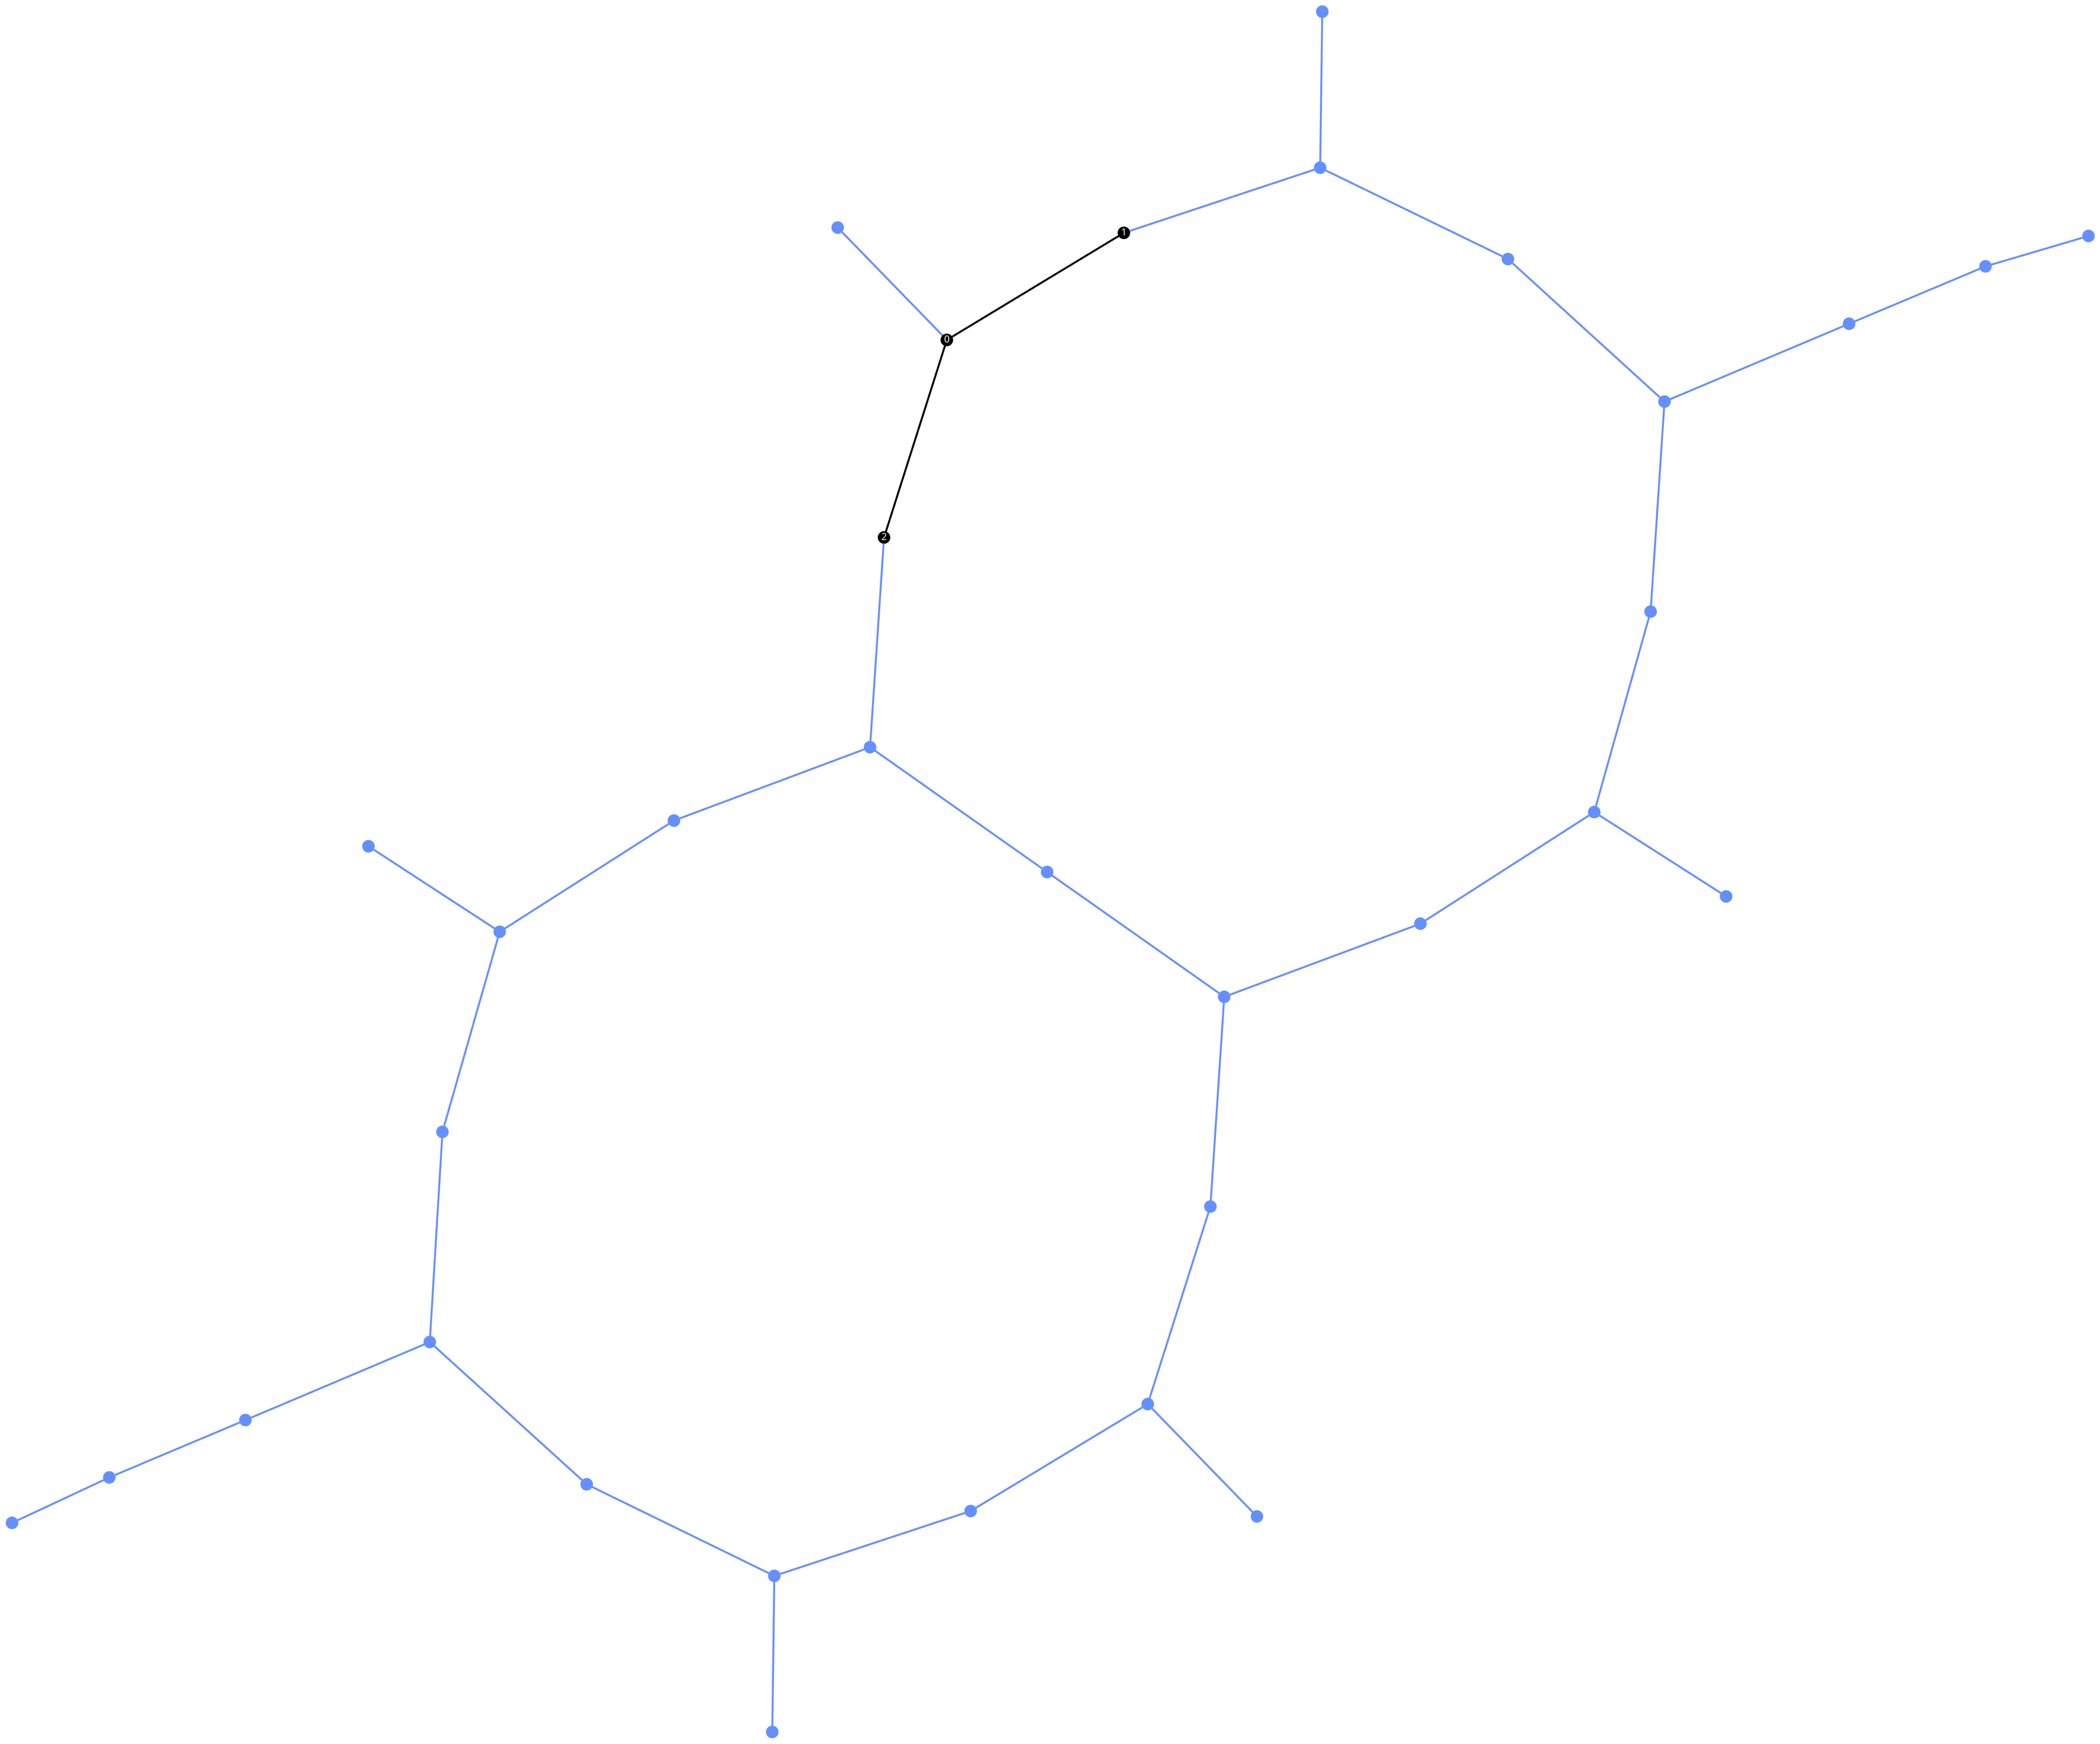

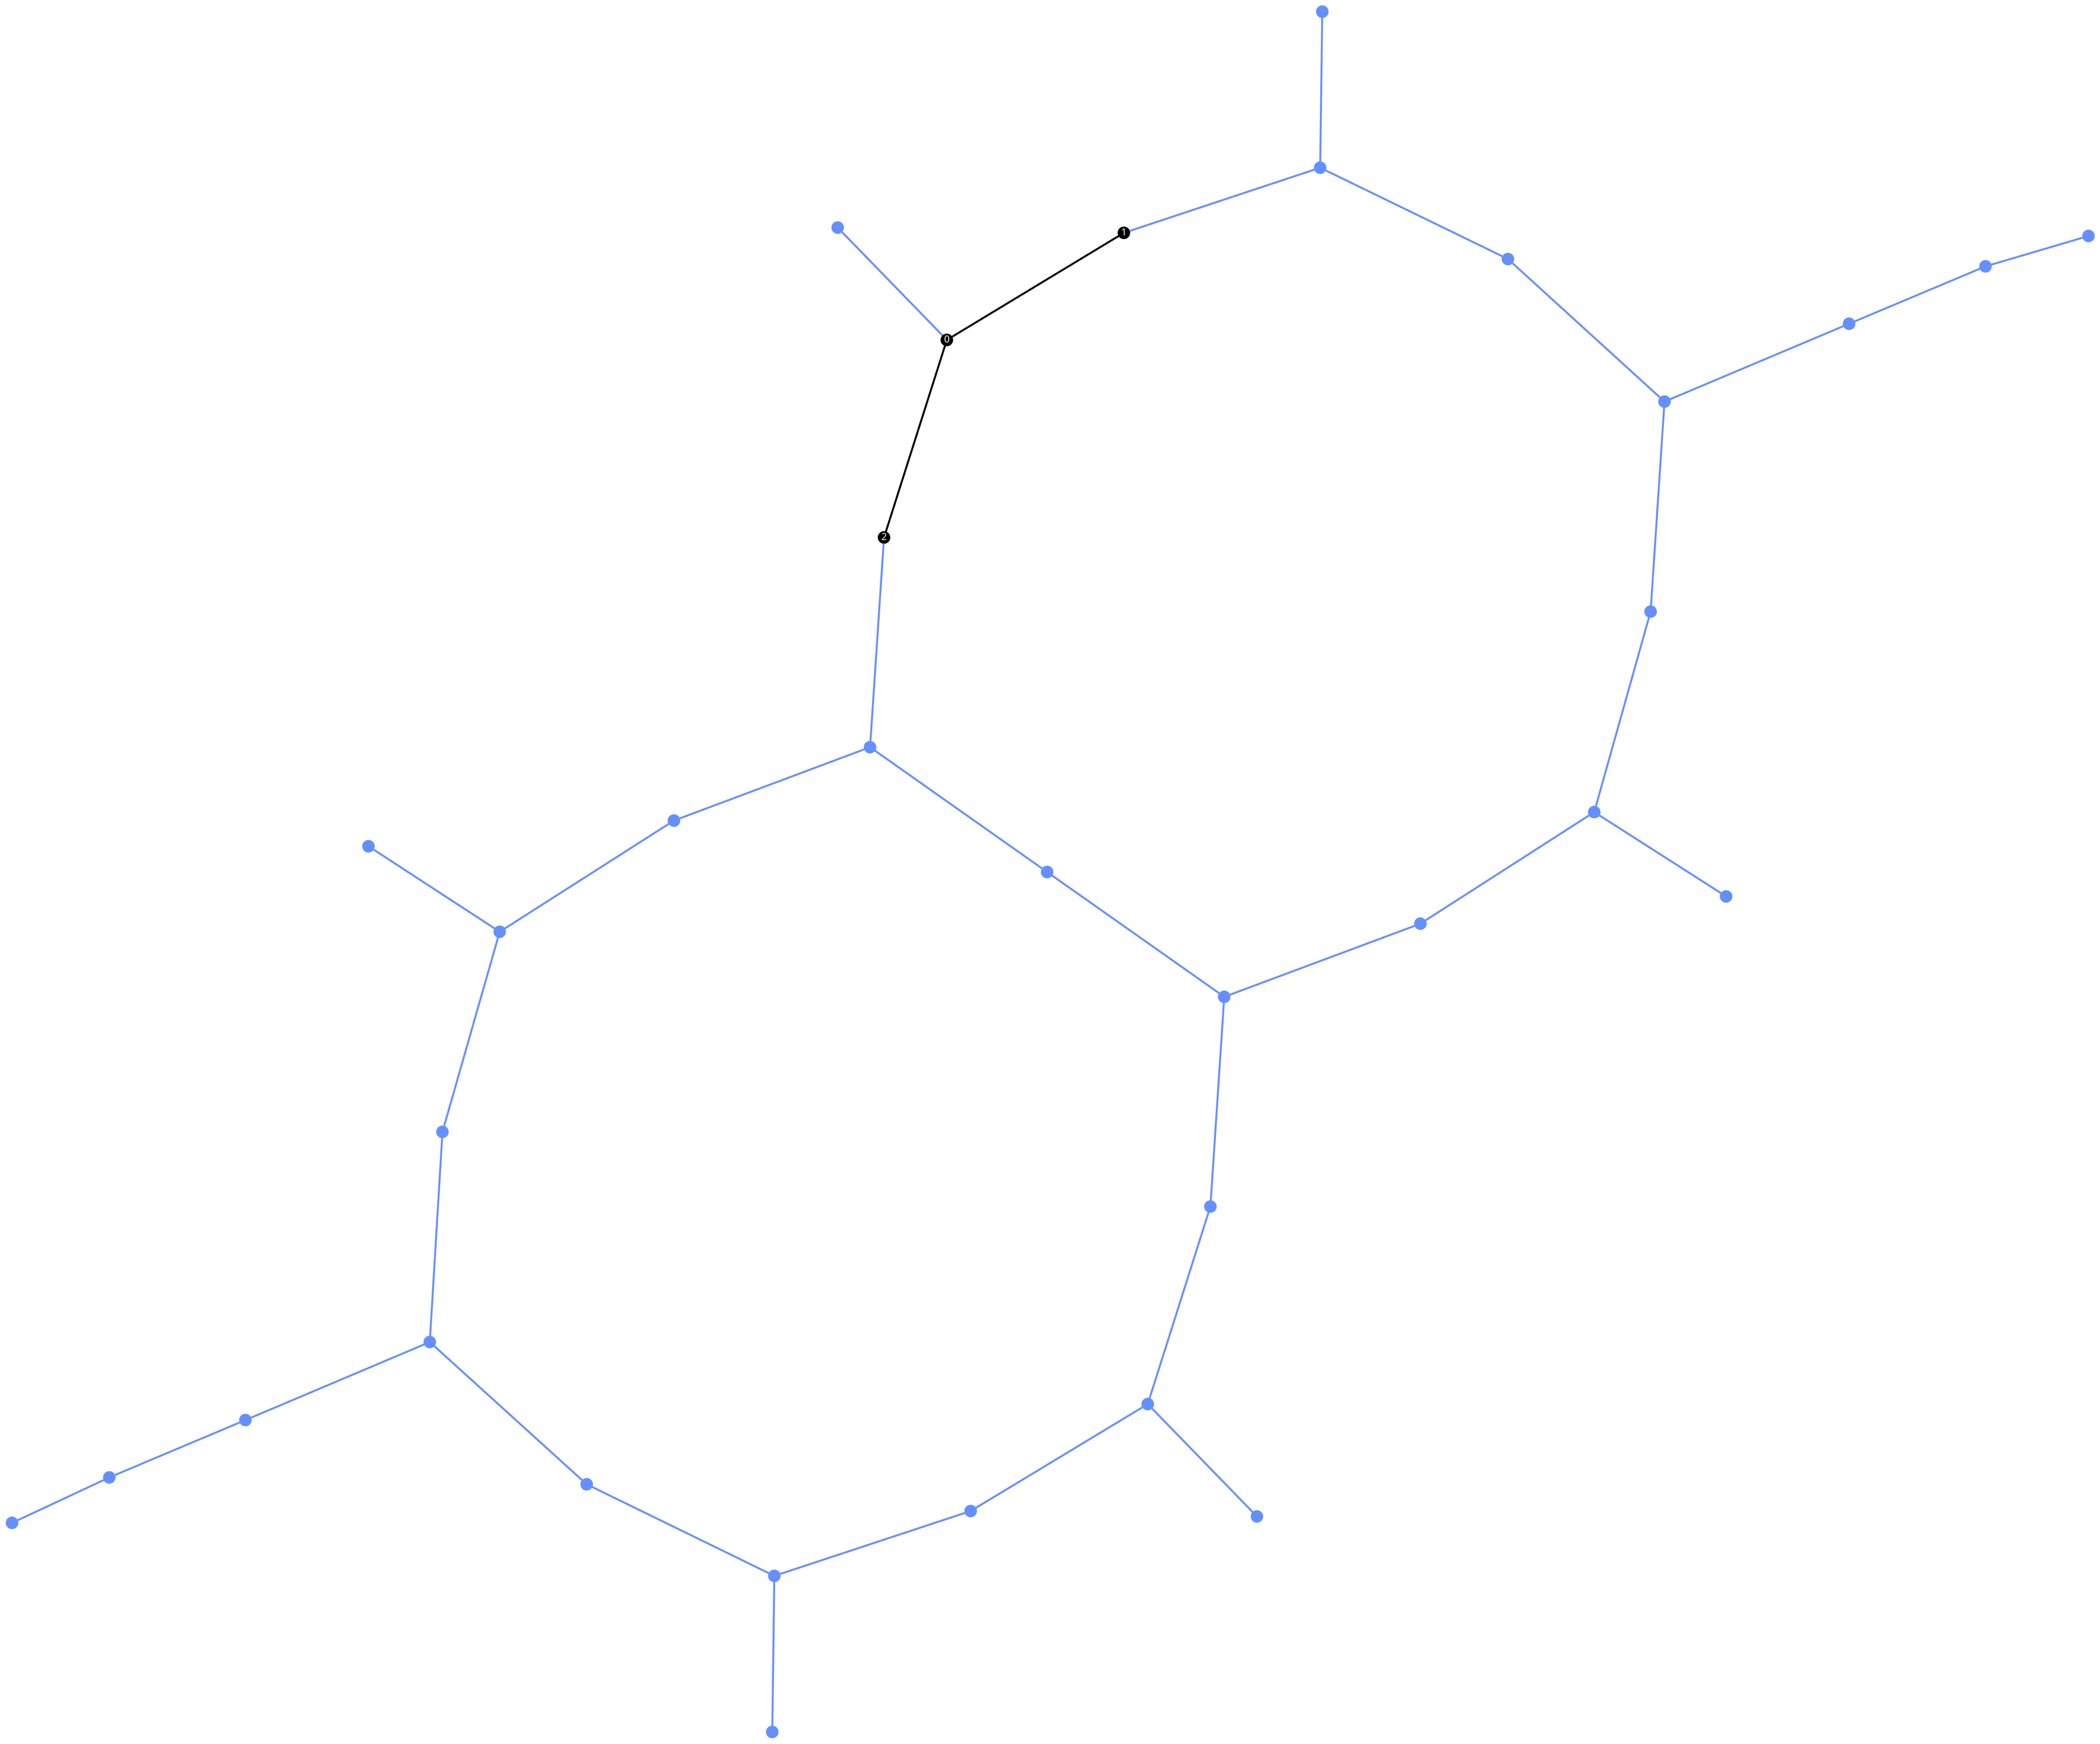

In [11]:
from qiskit.visualization import plot_circuit_layout

plot_circuit_layout(transpiled, backend)


## Interacting with the transpilation process

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.transpiler.generate_preset_pass_manager 

Some parameters can be used to change the behavior of the transpiler:
- optimization_level: from 0 (no optimization) to 3 (heavy optimization)
- backend: use the description of the backend object (basis gates, coupling map, target) as transpiler's input
- initial_layout: provide manually the mapping of the logical qubits to the physical ones
- seed_transpiler: a random number for the sochastic parts of the compiler. Use it to have deterministic outputs


If the backend is not provided, we can feed the transpiler with those parameters:
- basis_gates: provide a list a basis gates that can be used by the transpiler (from a real backend, backend.operation_names)
- coupling_map: the list of adjacency matrix, with directed two-qubits interactions (from a real backend, backend.coupling_map)


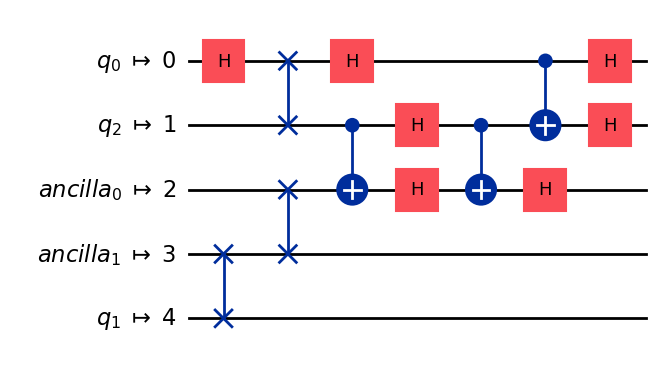

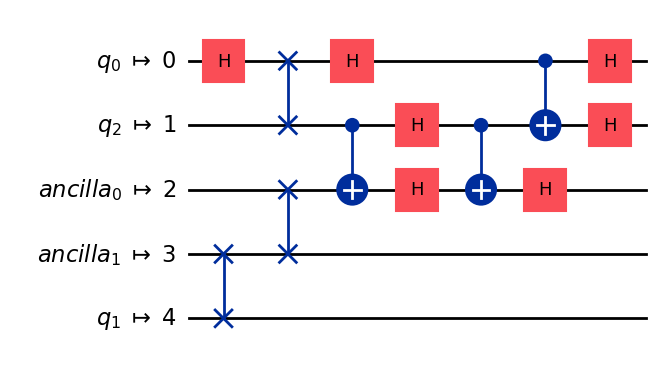

In [19]:
from qiskit.transpiler import CouplingMap

cm = CouplingMap([[0, 1], [1, 2], [2, 3], [3,4]])  # linear 5-qubit device 0->1->2->3->4->5
basis = ['h', 'swap', 'cx']

pass_manager_custom = generate_preset_pass_manager(
    optimization_level=3,
    coupling_map=cm,
    basis_gates=basis,
    initial_layout=[0, 4, 1]  # map logical qubits to physical ones q0->0, q1->4, q2 -> 1
)

transpiled = pass_manager_custom.run(qc)
transpiled.draw("mpl", idle_wires=False) 